# GOES-18 ABI Full Disk — a single band (10.3 µm)

The most general view first: one infrared band over the **whole Full Disk**,
then the same band zoomed to a domain with a colour bar.

`C13` is the clean infrared window at 10.3 µm. It measures brightness
temperature, so it works day and night: cold cloud tops are bright here
(`gray_r`), the warm surface is dark.


## Environment

Everything runs in the environment described by
[`environment.yml`](../environment.yml) at the repository root:

```bash
conda env create -f environment.yml
conda activate goes-viirs
python -m jupyter lab
```


## Setup

In [1]:
import logging
import sys
import warnings
from pathlib import Path

from IPython.display import Image, display
from satpy import Scene
from satpy.utils import PerformanceWarning

logging.getLogger("pyspectral.rsr_reader").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=PerformanceWarning)
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.domains import DOMAINS
from examples.goes18_coverage_data import SCAN_LABELS, download_coverage
from examples.render_satellite import (
    crop_and_resample_scene,
    resample_to_max_size,
    save_band_map,
    save_dataset_with_lonlat_grid,
    save_map,
)


## 1. Get the data

In [2]:
COVERAGE = "full_disk"
CHANNELS = ("C13",)

# Where the NetCDF files live. download_coverage() fetches anything missing
# from the public NOAA bucket and reuses whatever is already on disk.
DATA_DIR = REPO_ROOT / "data" / "goes18-20231003-1900"
files = download_coverage(DATA_DIR, COVERAGE, CHANNELS)

print(f"folder: {DATA_DIR / COVERAGE}")
print(f"{len(files)} file(s):")
for name in files:
    print("  ", Path(name).name)


folder: /Users/rmsm1/Desktop/Shishaldin_paper/GOES-VIIRS-Imagery-Guide/data/goes18-20231003-1900/full_disk
1 file(s):
   OR_ABI-L1b-RadF-M6C13_G18_s20232761900206_e20232761909526_c20232761909572.nc


## 2. Plot the complete Full Disk

The whole disk on its own grid, reduced in size so it draws quickly.


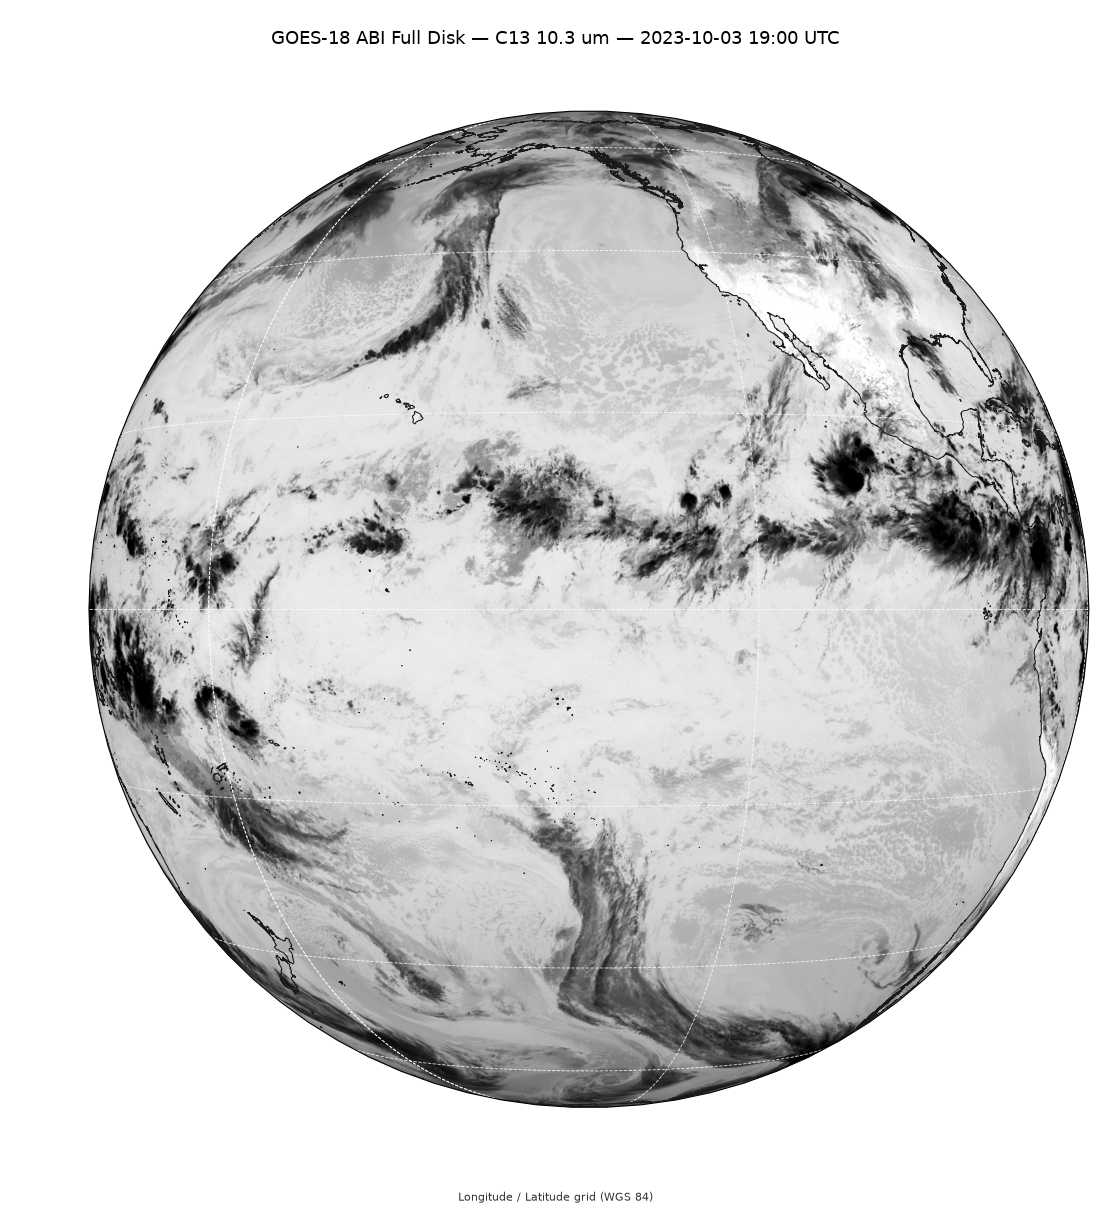

In [3]:
BAND = "C13"
scene = Scene(reader="abi_l1b", filenames=files)
scene.load([BAND])

full = resample_to_max_size(scene, BAND, max_size=1400)
out_full = REPO_ROOT / "output" / "full_disk_C13.png"
save_dataset_with_lonlat_grid(
    full, BAND, out_full,
    title=f"GOES-18 ABI Full Disk — {BAND} 10.3 um — {SCAN_LABELS['full_disk']}",
    dpi=100,
)
display(Image(filename=str(out_full)))


## 3. Choose a domain

From the whole disk down to the area of interest around Shishaldin.


In [4]:
DOMAIN_NAME = "shishaldin_big"
DOMAIN = DOMAINS[DOMAIN_NAME]
RESOLUTION = 0.02

print(f"{DOMAIN_NAME}: {DOMAIN}")


shishaldin_big: (-169.0, 52.5, -159.0, 57.0)


## 4. Plot the domain with a colour bar

Brightness temperature in kelvin, so the values can be read off the scale.


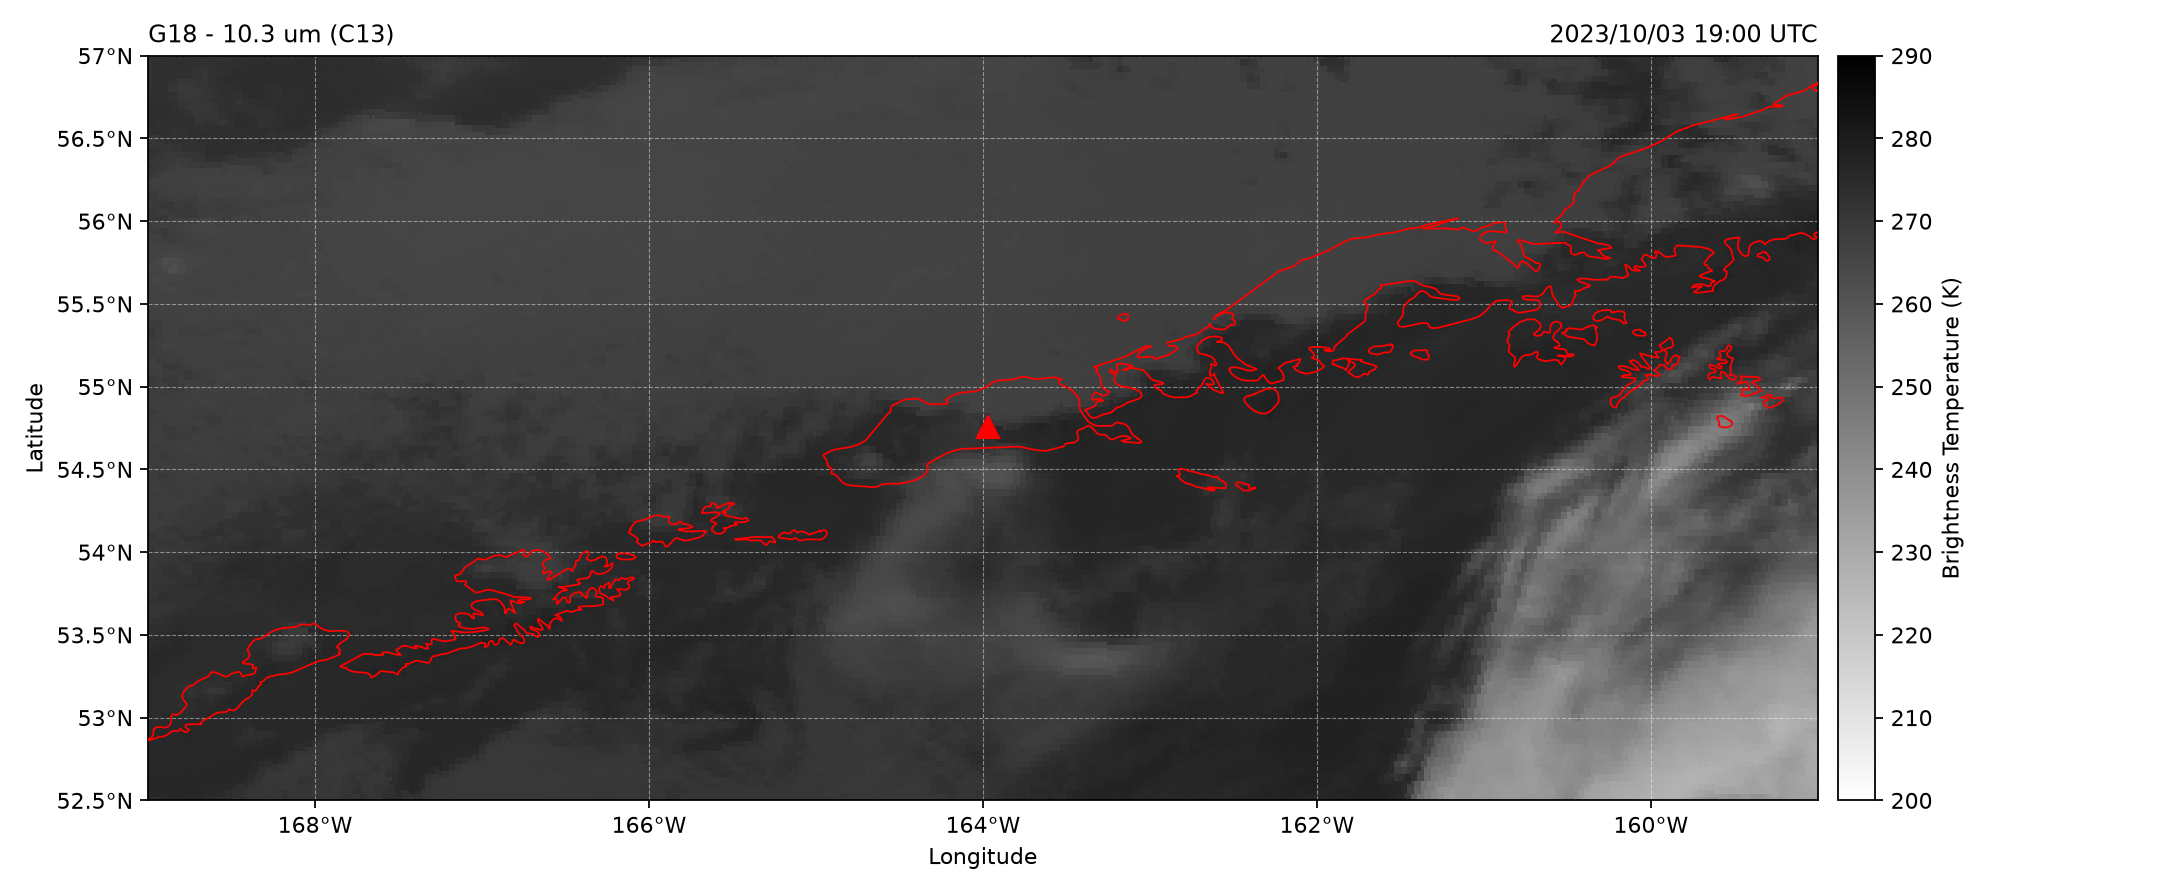

In [5]:
cropped = crop_and_resample_scene(scene, domain=DOMAIN, resolution=RESOLUTION)
out_domain = REPO_ROOT / "output" / "full_disk_domain_C13.png"
save_band_map(
    cropped, BAND, out_domain,
    title="G18 - 10.3 um (C13)",
    cmap="gray_r", vmin=200, vmax=290,
    colorbar_label="Brightness Temperature (K)",
)
display(Image(filename=str(out_domain)))


## Notes

* Change `vmin`/`vmax` to stretch the grey scale differently.
* Any other band works the same way: load it and pass its name to
  `save_band_map`.
* For a brightness-temperature *difference* (for example C14 − C15), compute the
  difference and pass it with a diverging colour map.
